# Table ARI values (alternative to the overview plot)

Note: this takes computed ARI values from the "figure" script and does not compute the ARI values locally.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import corc.graph_metrics.neb
import corc.utils
import corc.our_datasets
import corc.our_algorithms
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tqdm
import time 
import scipy

cache_path="../../cache"

# Compute everything in the notebook directly from the data

In [4]:

all_aris = pickle.load(open(os.path.join(cache_path,"all_aris.pkl"), "rb"))

In [5]:
all_aris["BHC"]

{'densired_circles_8': [np.float64(0.5037706702860093),
  np.float64(0.30811702087175524),
  np.float64(0.23724967282348802),
  np.float64(0.3129194048150202),
  np.float64(0.41774798984446126),
  np.float64(0.5981526579737116),
  np.float64(0.40955874803600456),
  np.float64(0.5234663806578549),
  np.float64(0.5006766988536807),
  np.float64(0.4787587613292621)],
 'densired_circles_16': [np.float64(0.26029416611693834),
  np.float64(0.2575469347857312),
  np.float64(-0.0005678288795312962),
  np.float64(0.23982008226997753),
  np.float64(0.1997950200135963),
  np.float64(0.2189892335410007),
  np.float64(0.23018009757782695),
  np.float64(0.38563369301565603),
  np.float64(0.3137110149121255),
  np.float64(0.2767378626824425)],
 'densired_circles_32': [np.float64(0.0743554919493994),
  np.float64(0.06547107392487296),
  np.float64(0.05936646397535),
  np.float64(0.23839854253416767),
  np.float64(0.0011600051608612132),
  np.float64(0.21377524215320837),
  np.float64(0.153425558765179

In [3]:
all_aris = {}

In [ ]:
datasets = corc.our_datasets.CORE_HD_DATASETS
algorithms = corc.our_algorithms.CORE_SELECTOR
# algorithms = ["TMM-NEB", "GMM-NEB"]
# datasets = ["mnist8"]

start_time = time.time()
# all_aris = dict()
for algorithm in algorithms:
    if algorithm not in all_aris.keys() or all_aris[algorithm] is None:
        all_aris[algorithm] = dict()
    for dataset in tqdm.tqdm(datasets, desc=f"Processing algorithm {algorithm.replace("\n", ' ')}"):
        if dataset in all_aris[algorithm].keys():
            continue
        aris = list()
        # if dataset.startswith("densired"):
        for index in range(10):
            # print(f"Processing {dataset} index {index}")
            X, y, _ = corc.utils.load_dataset(
                dataset, index=index, cache_path=cache_path
            )
            algos = corc.utils.load_algorithms(
                dataset, algorithm, cache_path=cache_path, index=index
            )
            if algos is not None:
                ari_scores = corc.utils.get_ari(algos, X, y)
                aris.append(np.mean(ari_scores))  # note the "mean" in here
        # else:
        #     X, y, _ = corc.utils.load_dataset(dataset, cache_path=cache_path)
        #     algos = corc.utils.load_algorithms(
        #         dataset, algorithm, cache_path=cache_path
        #     )
        #     if algos is not None:
        #         ari_scores = corc.utils.get_ari(algos, X, y)
        #         aris.append(ari_scores)
        all_aris[algorithm][dataset] = aris

import pickle

with open(os.path.join(cache_path, "all_aris.pkl"), "wb") as f:
    pickle.dump(all_aris, f)

print(f"overall computation took {time.time() - start_time:.2f} seconds")

Processing algorithm Agglomerative
Clustering:   0%|          | 0/12 [00:00<?, ?it/s]

/mnt/vast-nhr/projects/nim00012/environments_martin/micromamba/envs/tneb2/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator AgglomerativeClustering from version 1.3.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/mnt/vast-nhr/projects/nim00012/environments_martin/micromamba/envs/tneb2/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator AgglomerativeClustering from version 1.3.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/mnt/vast-nhr/projects/nim00012/environments_martin/micromamba/envs/tn

6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters i

Processing algorithm GWG-dip:  17%|█▋        | 2/12 [00:13<01:03,  6.37s/it]

6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.


In [8]:
def _fmt_mean_std(val):
    if isinstance(val, list):
        mean = np.mean(val)
        std = np.std(val, ddof=1)
        return f"{mean:.2f}±{std:.2f}"
    # single number → just format it (no std)
    return f"{val:.2g}"


# Build DataFrame where each cell holds “mean ± std” (or the value itself)
purity_df = pd.DataFrame(
    {
        (
            corc.our_algorithms.ALG_DISPLAYNAMES[algo]
            if algo in corc.our_algorithms.ALG_DISPLAYNAMES
            else algo
        ).replace("\n", " "): {
            ds: _fmt_mean_std(scores) for ds, scores in ds_dict.items()
        }
        for algo, ds_dict in all_aris.items()
    },
).T

print(purity_df)


# Convert to LaTeX – keep the “±” symbol by disabling escaping
latex_str = purity_df.to_latex(
    index=True,
    escape=False,
    # hrules=True,
    label="tab:overview_hd",
    caption="Overview of the performance of the algorithms on the datasets. The best performing algorithm is highlighted in green, the second best in orange, and the third best in light blue.",
    # convert_css=True,
)

with open("../../figures/table_ari-with-filter.tex", "wb") as f:
    f.write(latex_str.encode("utf-8"))

                         densired_circles_8 densired_circles_16  \
t-NEB (ours)                      0.91±0.13           0.98±0.05   
g-NEB (ours)                      0.86±0.20           0.95±0.09   
Agglomerative Clustering          0.71±0.10           0.67±0.13   
HDBSCAN                           0.15±0.30           0.34±0.42   
Gaussian Mixture                  0.65±0.12           0.66±0.13   
Leiden                            0.75±0.10           0.66±0.14   
GWG-dip                           0.16±0.20           0.79±0.13   
UniForCE                          0.09±0.07           0.17±0.19   
SMMP                              0.57±0.19           0.69±0.13   
BHC                               0.43±0.11           0.24±0.10   

                         densired_circles_32 densired_circles_64  \
t-NEB (ours)                       0.99±0.02           0.99±0.03   
g-NEB (ours)                       0.90±0.21           0.90±0.19   
Agglomerative Clustering           0.67±0.15           0.6

In [16]:
dataset = "densired_circles_8"
dataset = "noisy_moons"
algorithm = "BHC"


X,y,_ = corc.utils.load_dataset(dataset, cache_path=cache_path, index=0)
algos = corc.utils.load_algorithms(dataset, algorithm, cache_path=cache_path, index=0)

In [25]:
y_pred = algos[0].predict_with_target(X, 2)

In [26]:
import sklearn.metrics
sklearn.metrics.adjusted_rand_score(y, y_pred)

0.0

In [3]:
dataset = "mnist8"
X,y,tsne = corc.utils.load_dataset(dataset, cache_path=cache_path)

In [5]:
algorithm_name = "BHC"
corc.utils.load_algorithms(dataset, cache_path=cache_path, algorithm=algorithm_name)

File ../../cache/cluster_objects/mnist8_BHC.pickle not found.


In [10]:
algo = algos[0]

In [13]:
algo.result.get_dendrogram()

array([[ 552,  919,   -1,   -1],
       [1000,  505,   -1,   -1],
       [1001,  778,   -1,   -1],
       ...,
       [1995,  963,   -1,   -1],
       [1996,  187,   -1,   -1],
       [1997,  668,   -1,   -1]])

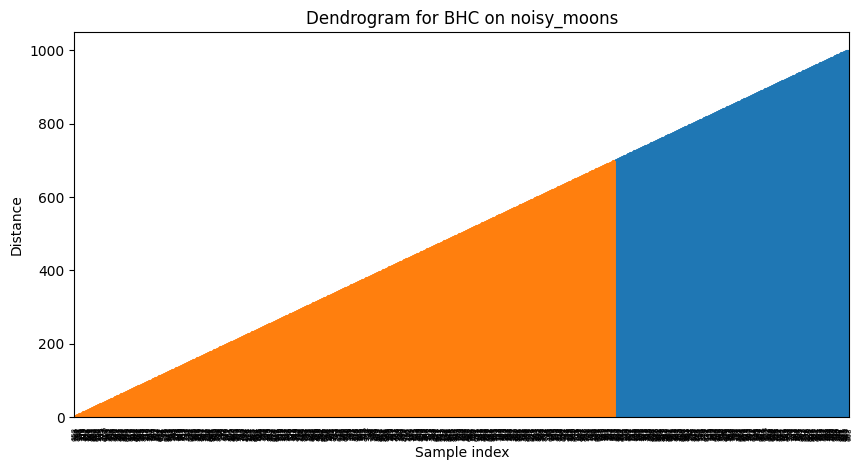

In [33]:
dendrogram = algo.result.get_dendrogram().astype(np.float64)
n_links = dendrogram.shape[0]
dendrogram[:, 2] = np.arange(1, n_links + 1, dtype=np.float64)

counts = np.ones(dendrogram.shape[0] + 1, dtype=int)   # each original sample = 1
for i, (c1, c2) in enumerate(dendrogram[:, :2].astype(int)):
    counts = np.append(counts, counts[c1] + counts[c2])
    dendrogram[i, 3] = counts[-1]    
plt.figure(figsize=(10, 5))
scipy.cluster.hierarchy.dendrogram(dendrogram)
plt.title("Dendrogram for BHC on noisy_moons")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

In [38]:
algo.result.arc_list[:10]

array([1000 -> 552, 1000 -> 919, 1001 -> 1000, 1001 -> 505, 1002 -> 1001,
       1002 -> 778, 1003 -> 1002, 1003 -> 962, 1004 -> 1003, 1004 -> 793],
      dtype=object)

In [44]:
algo.build()

Time taken for initial pairwise calculations: 4.89 seconds


Merging clusters:   4%|▍         | 44/999 [00:07<02:38,  6.02it/s]

[[  0.           1.           5.58968292  -3.53258299  -9.12226591]
 [  0.           2.          -3.23928903 -12.26247904  -9.02319001]
 [  0.           3.          -1.17658852 -10.22171715  -9.04512863]
 ...
 [997.         998.          -4.96118793 -14.08389352  -9.12270559]
 [997.         999.          -2.47634387 -11.58742601  -9.11108214]
 [998.         999.          -3.84701115 -12.91872526  -9.07171411]]


Merging clusters: 100%|██████████| 999/999 [30:05<00:00,  1.81s/it]    

Time taken for merging: 1805.96 seconds
Time taken for new comparisons: 1801.03 seconds


<function matplotlib.pyplot.show(close=None, block=None)>

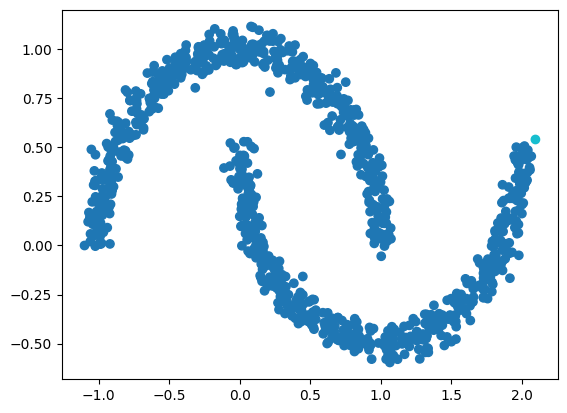

In [28]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap="tab10",)
plt.show

In [9]:
for dataset in datasets:
    # if dataset.startswith("densired"):
    #     continue
    print(f"\nDataset: {dataset}")
    # algo1 = "TMM-NEB"
    # algo1 = "Leiden"
    for algo1 in ["TMM-NEB", "Leiden", "Agglomerative\nClustering", "GWG-dip", "Gaussian\nMixture", "SMMP"]:
        for algo2 in algorithms:
            if algo1 == algo2:
                continue
            aris1 = all_aris[algo1][dataset]
            aris2 = all_aris[algo2][dataset]
            if len(aris1) < 2:
                aris1 = np.ones(10)*aris1[0]
            if len(aris2) < 2:
                aris2 = np.ones(10)*aris2[0]                
            t_stat, p_val = scipy.stats.ttest_ind(aris1, aris2)

            clean_algo1 = algo1.replace("\n"," ")
            clean_algo2 = algo2.replace("\n"," ")
            if p_val > 0.05:
                print(f"{clean_algo1} vs {clean_algo2}: t={t_stat:.2f}, p={p_val:.3f}")
# scipy.stats.ttest_ind(all_aris['TMM-NEB'][dataset], all_aris[])


Dataset: densired_circles_8
TMM-NEB vs GMM-NEB: t=0.68, p=0.507
Leiden vs Agglomerative Clustering: t=0.85, p=0.407
Leiden vs Gaussian Mixture: t=1.95, p=0.067
Leiden vs GMM-NEB: t=-1.52, p=0.146
Agglomerative Clustering vs Gaussian Mixture: t=1.21, p=0.241
Agglomerative Clustering vs Leiden: t=-0.85, p=0.407
Agglomerative Clustering vs GMM-NEB: t=-2.07, p=0.053
GWG-dip vs HDBSCAN: t=0.14, p=0.892
GWG-dip vs UniForCE: t=1.08, p=0.293
Gaussian Mixture vs Agglomerative Clustering: t=-1.21, p=0.241
Gaussian Mixture vs Leiden: t=-1.95, p=0.067
Gaussian Mixture vs SMMP: t=1.18, p=0.255
SMMP vs Gaussian Mixture: t=-1.18, p=0.255
SMMP vs BHC: t=2.02, p=0.059

Dataset: densired_circles_16
TMM-NEB vs GMM-NEB: t=0.86, p=0.399
Leiden vs Agglomerative Clustering: t=-0.23, p=0.824
Leiden vs Gaussian Mixture: t=-0.11, p=0.912
Leiden vs SMMP: t=-0.56, p=0.581
Agglomerative Clustering vs Gaussian Mixture: t=0.12, p=0.907
Agglomerative Clustering vs Leiden: t=0.23, p=0.824
Agglomerative Clustering vs 

# use ari values from image generation script

In [3]:
# filename = os.path.join(cache_path, "metrics", "figure2_main.pkl")
# with open(filename, "rb") as f:
#     data = pickle.load(f)
# filename = os.path.join(cache_path, "metrics", "figure2_main-full.pkl")
filename = os.path.join(cache_path, "metrics", "figure2-full.pkl")
# filename = os.path.join(cache_path, "metrics", "figure1-full.pkl")
with open(filename, "rb") as f:
    data = pickle.load(f)

In [8]:
import corc.our_algorithms
def style_col(col):
    ranked = col.rank(method='min', ascending=False)
    return ['background-color: lightgreen' if ranked.loc[i] == 1 else 
            'background-color: orange' if ranked.loc[i] == 2 else 
            'background-color: lightblue' if ranked.loc[i] == 3 else '' 
            for i in col.index]

def style_df(df):
    styled_df = df.style
    for col in df.columns:
        styled_df = styled_df.apply(style_col, subset=[col])
    return styled_df

def get_styled_table(data, operation=np.mean, core_algos=True):
    table = []
    for key in data.keys(): # datasets
        dict2 = data[key]
        row = []
        # print(dict2.keys())
        for key, value in dict2.items(): # algorithms
            if key not in corc.our_algorithms.CORE_SELECTOR and core_algos:
                continue
            # print(value)
            row.append(operation(value))
            # row.append(d[0])
        table.append(row)

    dataset_labels = [corc.our_datasets.dataset_displaynames[key] for key in data.keys()]
    algorithm_labels = list(data[list(data.keys())[0]].keys())
    if core_algos:
        algorithm_labels = [algo for algo in algorithm_labels if algo in corc.our_algorithms.CORE_SELECTOR]
    algorithm_labels = [corc.our_algorithms.ALG_DISPLAYNAMES[algo] if algo in corc.our_algorithms.ALG_DISPLAYNAMES else algo for algo in algorithm_labels]

    dataset_labels = [dataset.replace("\n", " ") for dataset in dataset_labels]
    algorithm_labels = [algo.replace("\n", " ") for algo in algorithm_labels]
    df = pd.DataFrame(table, columns=algorithm_labels, index=dataset_labels)
    df = df.transpose()
    # df
    df = df.map(lambda x: f"{x:.2f}")
    styled_df = style_df(df)
    return styled_df

get_styled_table(data, np.mean , core_algos=True)

KeyError: 'densired8'

In [19]:
get_styled_table(data, np.max)

,Densired 'circles' 8D,Densired 'circles' 16D,Densired 'circles' 32D,Densired 'circles' 64D,Densired 'Stud-t' 8D,Densired 'Stud-t' 16D,Densired 'Stud-t' 32D,Densired 'Stud-t' 64D,MNIST-Nd 8D,MNIST-Nd 16D,MNIST-Nd 32D,MNIST-Nd 64D
Agglomerative Clustering,0.68,0.66,0.59,0.75,0.56,0.87,0.90,0.64,0.80,0.68,0.62,0.49
HDBSCAN,0.00,0.00,0.44,0.00,0.01,0.00,0.00,0.00,0.03,0.06,0.07,0.07
Gaussian Mixture,0.79,0.77,0.69,0.91,0.74,0.68,0.49,0.42,0.89,0.74,0.73,0.62
Leiden,0.83,0.77,0.76,0.89,0.89,0.93,0.91,0.80,0.89,0.92,0.93,0.71
GWG-dip,0.98,1.00,1.00,0.98,0.09,0.72,0.25,0.50,0.89,0.85,0.49,0.53
UniForCE,0.32,0.24,0.47,0.14,0.25,0.34,0.45,0.78,0.13,0.13,0.05,0.03
SMMP,0.81,0.74,0.67,0.90,0.15,0.28,0.52,0.39,0.36,0.56,0.23,0.13
g-NEB (ours),1.00,1.00,1.00,0.99,0.77,0.72,0.74,0.34,0.77,0.62,0.56,0.40
t-NEB (ours),0.92,1.00,0.94,0.96,0.89,0.94,0.94,0.74,0.77,0.92,0.79,0.64


In [23]:
get_styled_table(data, lambda x: np.max(x)-np.min(x))

,Densired 'circles' 8D,Densired 'circles' 16D,Densired 'circles' 32D,Densired 'circles' 64D,Densired 'Stud-t' 8D,Densired 'Stud-t' 16D,Densired 'Stud-t' 32D,Densired 'Stud-t' 64D,MNIST-Nd 8D,MNIST-Nd 16D,MNIST-Nd 32D,MNIST-Nd 64D
Agglomerative Clustering,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
HDBSCAN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Gaussian Mixture,0.35,0.14,0.20,0.38,0.35,0.30,0.48,0.22,0.14,0.13,0.10,0.11
Leiden,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GWG-dip,0.47,0.34,0.24,0.22,0.08,0.72,0.19,0.50,0.21,0.26,0.35,0.26
UniForCE,0.38,0.23,0.49,0.11,0.18,0.10,0.49,0.46,0.11,0.09,0.03,0.02
SMMP,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
g-NEB (ours),0.02,0.00,0.00,0.06,0.15,0.72,0.74,0.34,0.14,0.17,0.15,0.26
t-NEB (ours),0.07,0.09,0.22,0.19,0.14,0.19,0.31,0.19,0.12,0.14,0.05,0.21


In [7]:
get_styled_table(data, np.std)

,Densired 'circles' 8D,Densired 'circles' 16D,Densired 'circles' 32D,Densired 'circles' 64D,Densired 'Stud-t' 8D,Densired 'Stud-t' 16D,Densired 'Stud-t' 32D,Densired 'Stud-t' 64D,MNIST-Nd 8D,MNIST-Nd 16D,MNIST-Nd 32D,MNIST-Nd 64D
Agglomerative Clustering,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
HDBSCAN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Gaussian Mixture,0.14,0.04,0.06,0.10,0.11,0.09,0.14,0.06,0.06,0.04,0.04,0.04
Leiden,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
UniForCE,0.10,0.09,0.18,0.04,0.06,0.03,0.17,0.13,0.03,0.03,0.01,0.01
SMMP,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
GWG-dip,0.16,0.11,0.09,0.07,0.03,0.24,0.07,0.15,0.06,0.07,0.12,0.08
g-NEB (ours),0.00,0.00,0.00,0.02,0.04,0.25,0.18,0.14,0.05,0.06,0.06,0.09
t-NEB (ours),0.03,0.04,0.08,0.06,0.04,0.04,0.09,0.07,0.06,0.05,0.01,0.06


In [8]:
my_table = styled_df.to_latex(
    hrules=True, 
    label="tab:overview_hd", 
    caption="Overview of the performance of the algorithms on the datasets. The best performing algorithm is highlighted in green, the second best in orange, and the third best in light blue.",
    convert_css=True,
)
my_table = my_table.replace("lightgreen", "darkblue!60")
my_table = my_table.replace("orange", "darkblue!30")
my_table = my_table.replace("lightblue", "darkblue!10")
print(my_table)

\begin{table}
\caption{Overview of the performance of the algorithms on the datasets. The best performing algorithm is highlighted in green, the second best in darkblue!30, and the third best in light blue.}
\label{tab:overview_hd}
\begin{tabular}{lllllllllllll}
\toprule
 & Densired 'circles' 8D & Densired 'circles' 16D & Densired 'circles' 32D & Densired 'circles' 64D & Densired 'Stud-t' 8D & Densired 'Stud-t' 16D & Densired 'Stud-t' 32D & Densired 'Stud-t' 64D & MNIST-Nd 8D & MNIST-Nd 16D & MNIST-Nd 32D & MNIST-Nd 64D \\
\midrule
Agglomerative Clustering & 0.68 & 0.66 & 0.59 & 0.75 & 0.56 & {\cellcolor{darkblue!10}} 0.87 & {\cellcolor{darkblue!10}} 0.90 & 0.64 & 0.80 & 0.68 & 0.62 & 0.49 \\
HDBSCAN & 0.00 & 0.00 & 0.44 & 0.00 & 0.01 & 0.00 & 0.00 & 0.00 & 0.03 & 0.06 & 0.07 & 0.07 \\
Gaussian Mixture & 0.79 & 0.77 & 0.69 & 0.91 & 0.74 & 0.68 & 0.49 & 0.42 & {\cellcolor{darkblue!60}} 0.89 & 0.74 & {\cellcolor{darkblue!10}} 0.73 & {\cellcolor{darkblue!10}} 0.62 \\
Leiden & 0.83 & 0.77 